In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score

In [3]:
# -- 模拟数据准备 --
# 假设 0： 健康， 1：肺炎（Pneumonia）
#真实情况（y_trur)
y_true = np.array([0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1])

#模型输出的概率（y_scores) - 这在工程中非常重要
#概率越高， 模型越觉得是肺炎
y_scores = np.array([0.1, 0.2, 0.85, 0.15, 0.05, 0.45, 0.9, 0.3, 0.7, 0.2, 0.1, 0.6, 0.35, 0.95, 0.8])

#1.设定一个“谨慎“的阈值
threshold = 0.5
y_pred = (y_scores >= threshold).astype(int)

In [4]:
# 2. 打印核心评估报告
print("=== 肺部 X 光片诊断评估报告 ===")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Pneumonia']))



=== 肺部 X 光片诊断评估报告 ===
              precision    recall  f1-score   support

     Healthy       0.89      1.00      0.94         8
   Pneumonia       1.00      0.86      0.92         7

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



当前阈值0.5下的F1分数：0.92


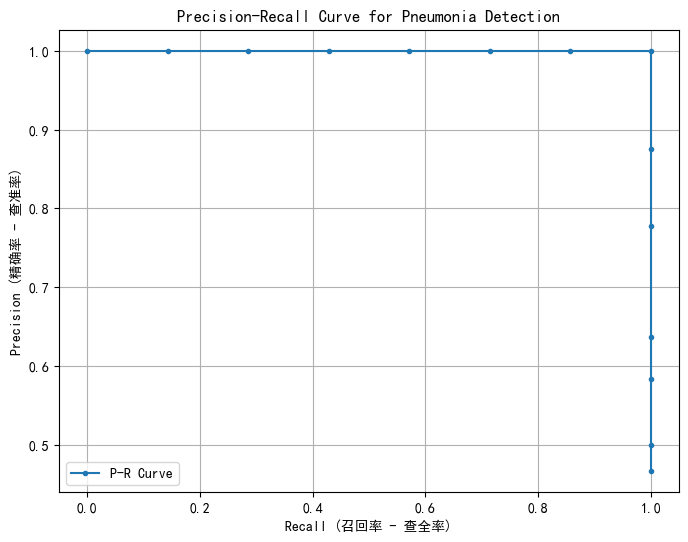

In [6]:
# 3. 计算F1分数
f1 = f1_score(y_true, y_pred)
print(f"当前阈值{threshold}下的F1分数：{f1:.2f}")

# --- 进阶：绘制 P-R 曲线 (Precision-Recall Curve) ---
# 这是资深工程师必看的，用来寻找“黄金平衡点”
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)


plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='P-R Curve')
plt.xlabel('Recall (召回率 - 查全率)')
plt.ylabel('Precision (精确率 - 查准率)')
plt.title('Precision-Recall Curve for Pneumonia Detection')
plt.grid(True)
plt.legend()
plt.show()